# Exploratory Data Analysis (EDA) for Artworks Dataset

This notebook performs Exploratory Data Analysis (EDA) on the Best Artworks of All Time dataset

The goal is to explore the dataset before using it for training a generative AI model that creates artworks inspired by famous artists.

In [ ]:

!pip install pandas numpy matplotlib seaborn pillow
!pip install kagglehub

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

## Download Dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("ikarus777/best-artworks-of-all-time")

print("Path to dataset files:", path)

100%|██████████| 2.29G/2.29G [00:24<00:00, 101MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ikarus777/best-artworks-of-all-time/versions/1


## Explore Dataset Structure

In [ ]:
import os

os.listdir(path)

['images', 'resized', 'artists.csv']

## Access Resized Images Folder

In [ ]:
resized_path = os.path.join(path, "resized")

os.listdir(resized_path)

['resized']

## Locate Image Files

In [ ]:
resized_path = os.path.join(path, "resized", "resized")

os.listdir(resized_path)

['Vincent_van_Gogh_511.jpg',
 'Edgar_Degas_310.jpg',
 'Rembrandt_173.jpg',
 'Francisco_Goya_2.jpg',
 'Henri_de_Toulouse-Lautrec_9.jpg',
 'Marc_Chagall_19.jpg',
 'Georges_Seurat_30.jpg',
 'Vincent_van_Gogh_848.jpg',
 'Michelangelo_24.jpg',
 'Pieter_Bruegel_2.jpg',
 'Edgar_Degas_80.jpg',
 'Francisco_Goya_73.jpg',
 'Albrecht_DuΓòá├¬rer_33.jpg',
 'Andy_Warhol_114.jpg',
 'Edgar_Degas_700.jpg',
 'Diego_Rivera_34.jpg',
 'Henri_Matisse_50.jpg',
 'Peter_Paul_Rubens_78.jpg',
 'Joan_Miro_10.jpg',
 'Mikhail_Vrubel_5.jpg',
 'Leonardo_da_Vinci_1.jpg',
 'Vincent_van_Gogh_109.jpg',
 'Francisco_Goya_226.jpg',
 'Francisco_Goya_11.jpg',
 'Pablo_Picasso_364.jpg',
 'Henri_Rousseau_57.jpg',
 'Paul_Klee_169.jpg',
 'Andy_Warhol_57.jpg',
 'Kazimir_Malevich_104.jpg',
 'Rene_Magritte_2.jpg',
 'Albrecht_Du╠êrer_289.jpg',
 'Vincent_van_Gogh_438.jpg',
 'Andrei_Rublev_15.jpg',
 'Andy_Warhol_36.jpg',
 'Andy_Warhol_167.jpg',
 'Paul_Gauguin_288.jpg',
 'Vincent_van_Gogh_726.jpg',
 'Vincent_van_Gogh_574.jpg',
 'Edgar_Deg

## Extract Artist Names from Image Files

In [ ]:
artists = os.listdir(resized_path)

print("Number of artists:", len(artists))
artists[:10]

Number of artists: 8683


['Vincent_van_Gogh_511.jpg',
 'Edgar_Degas_310.jpg',
 'Rembrandt_173.jpg',
 'Francisco_Goya_2.jpg',
 'Henri_de_Toulouse-Lautrec_9.jpg',
 'Marc_Chagall_19.jpg',
 'Georges_Seurat_30.jpg',
 'Vincent_van_Gogh_848.jpg',
 'Michelangelo_24.jpg',
 'Pieter_Bruegel_2.jpg']

## Image Distribution Across Artists

In [ ]:
artist_counts = {}

for img in artists:

    artist_name = "_".join(img.split("_")[:-1])

    if artist_name in artist_counts:
        artist_counts[artist_name] += 1
    else:
        artist_counts[artist_name] = 1

artist_counts

{'Vincent_van_Gogh': 877,
 'Edgar_Degas': 702,
 'Rembrandt': 262,
 'Francisco_Goya': 291,
 'Henri_de_Toulouse-Lautrec': 81,
 'Marc_Chagall': 239,
 'Georges_Seurat': 43,
 'Michelangelo': 49,
 'Pieter_Bruegel': 134,
 'Albrecht_DuΓòá├¬rer': 328,
 'Andy_Warhol': 181,
 'Diego_Rivera': 70,
 'Henri_Matisse': 186,
 'Peter_Paul_Rubens': 141,
 'Joan_Miro': 102,
 'Mikhail_Vrubel': 171,
 'Leonardo_da_Vinci': 143,
 'Pablo_Picasso': 439,
 'Henri_Rousseau': 70,
 'Paul_Klee': 188,
 'Kazimir_Malevich': 126,
 'Rene_Magritte': 194,
 'Albrecht_Du╠êrer': 328,
 'Andrei_Rublev': 99,
 'Paul_Gauguin': 311,
 'Titian': 255,
 'Piet_Mondrian': 84,
 'Salvador_Dali': 139,
 'Edouard_Manet': 90,
 'Amedeo_Modigliani': 193,
 'Pierre-Auguste_Renoir': 336,
 'Edvard_Munch': 67,
 'Alfred_Sisley': 259,
 'El_Greco': 87,
 'Raphael': 109,
 'Sandro_Botticelli': 164,
 'Frida_Kahlo': 120,
 'Jan_van_Eyck': 81,
 'Gustav_Klimt': 117,
 'Jackson_Pollock': 24,
 'Claude_Monet': 73,
 'Giotto_di_Bondone': 119,
 'Caravaggio': 55,
 'Camille_

## Convert Artist Counts to DataFrame

In [ ]:
df = pd.DataFrame(list(artist_counts.items()), columns=["Artist", "Number_of_Images"])

df.head()

,Artist,Number_of_Images
0,Vincent_van_Gogh,877
1,Edgar_Degas,702
2,Rembrandt,262
3,Francisco_Goya,291
4,Henri_de_Toulouse-Lautrec,81


## Sort Artists by Number of Images

In [ ]:
df = df.sort_values(by="Number_of_Images", ascending=False)

df.head(10)

,Artist,Number_of_Images
0,Vincent_van_Gogh,877
1,Edgar_Degas,702
17,Pablo_Picasso,439
30,Pierre-Auguste_Renoir,336
9,Albrecht_DuΓòá├¬rer,328
22,Albrecht_Du╠êrer,328
24,Paul_Gauguin,311
3,Francisco_Goya,291
2,Rembrandt,262
32,Alfred_Sisley,259


## Top 10 Artists by Number of Images

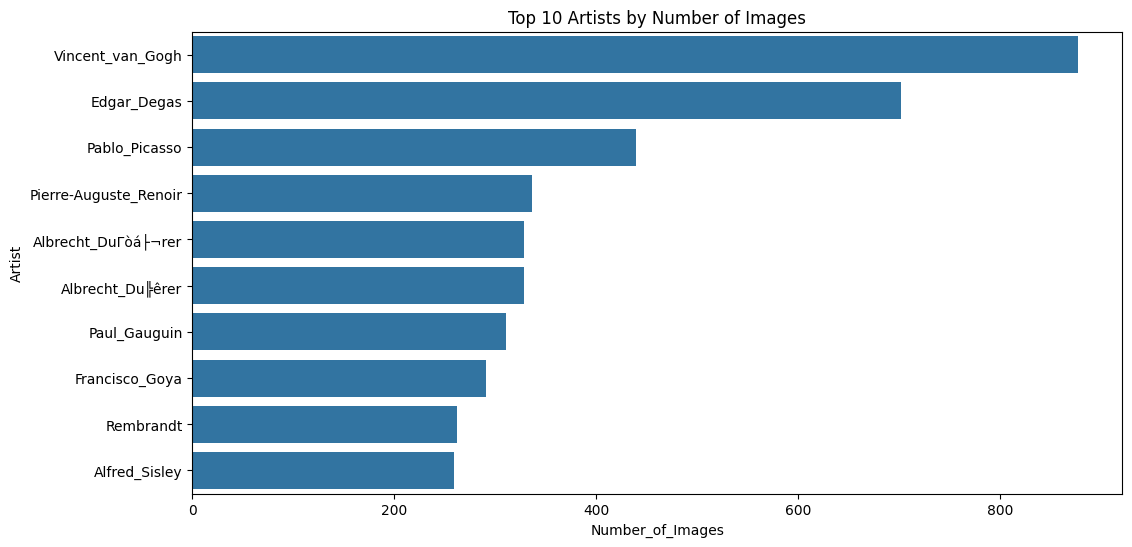

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="Number_of_Images",
    y="Artist",
    data=df.head(10)
)

plt.title("Top 10 Artists by Number of Images")
plt.show()

## Sample Images from the Dataset

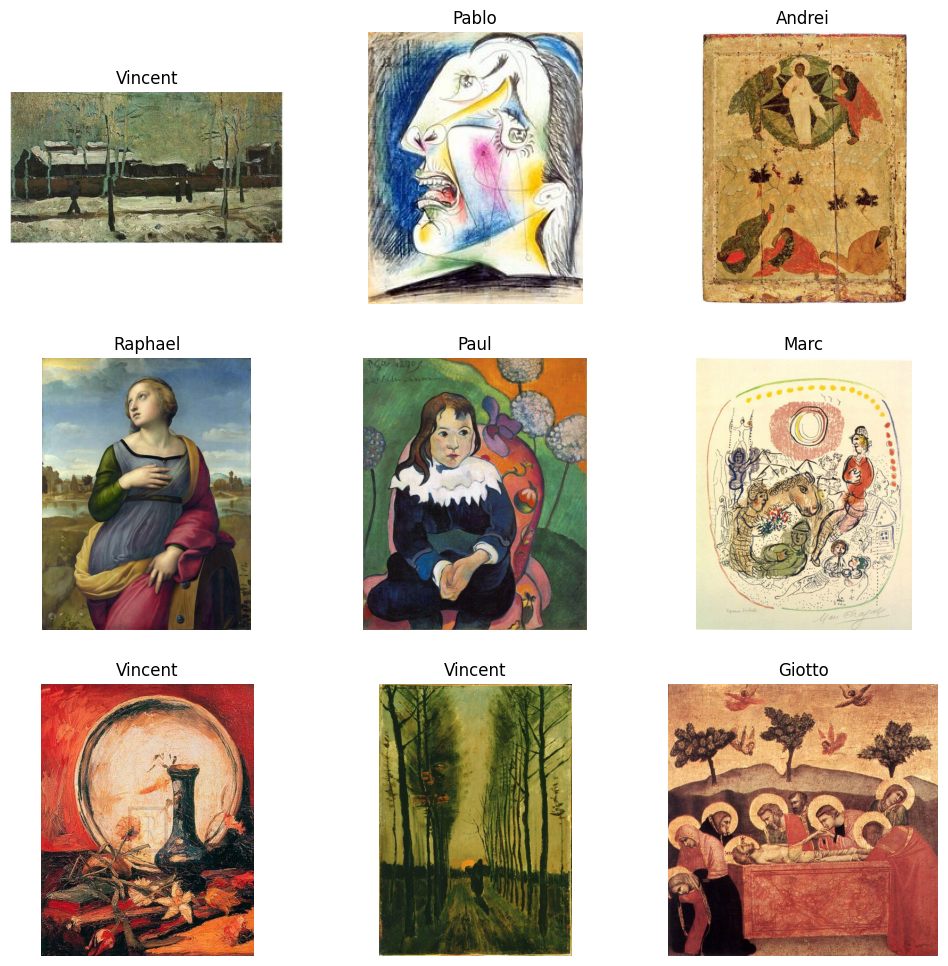

In [ ]:
import random

plt.figure(figsize=(12,12))

for i in range(9):

    img_name = random.choice(artists)

    img_path = os.path.join(resized_path, img_name)

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(img_name.split("_")[0])
    plt.axis("off")

plt.show()

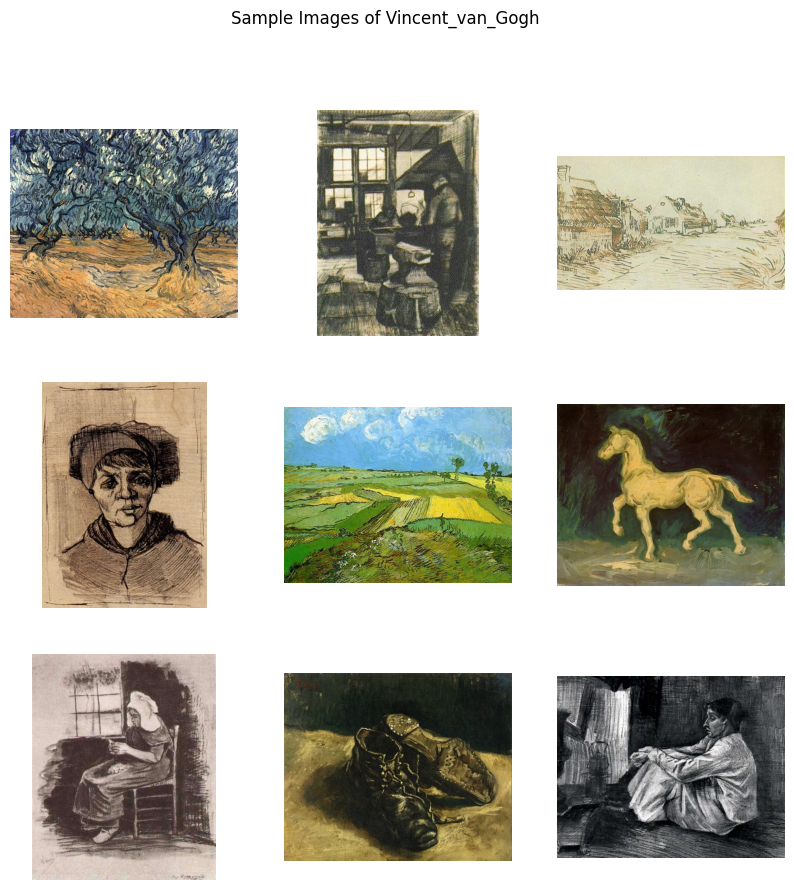

In [ ]:
artist_name = "Vincent_van_Gogh"

artist_images = [img for img in artists if artist_name in img]

plt.figure(figsize=(10,10))

for i in range(9):
    img_name = random.choice(artist_images)
    img = Image.open(os.path.join(resized_path, img_name))

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle(f"Sample Images of {artist_name}")
plt.show()

## Extract Image Dimensions

In [ ]:
sizes = []

for img_name in artists[:100]:

    img_path = os.path.join(resized_path, img_name)

    img = Image.open(img_path)

    sizes.append(img.size)

sizes[:10]

[(745, 614),
 (634, 460),
 (512, 614),
 (427, 614),
 (480, 674),
 (356, 461),
 (234, 288),
 (421, 614),
 (939, 627),
 (522, 614)]

## Image Width Distribution

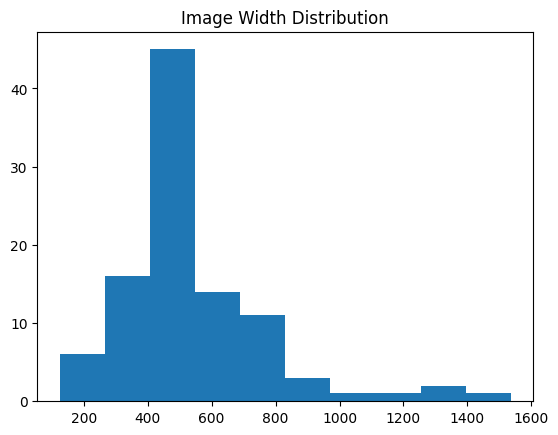

In [ ]:
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.hist(widths, bins=10)
plt.title("Image Width Distribution")
plt.show()

## Image Size Distribution

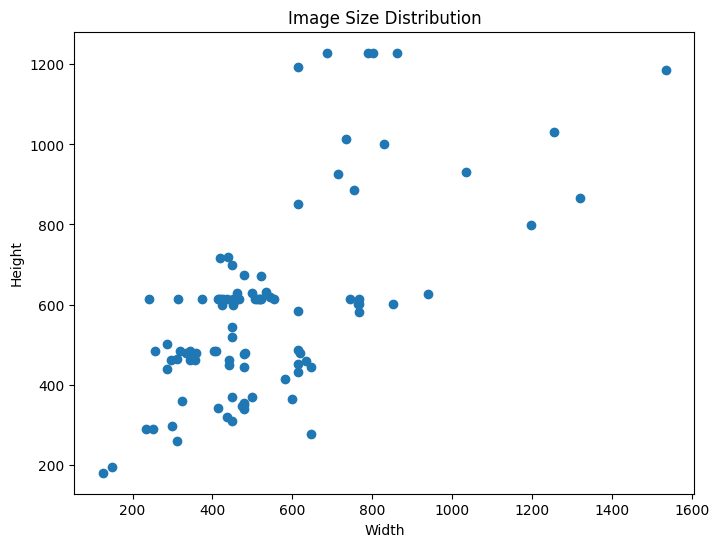

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(widths, heights)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")

plt.show()

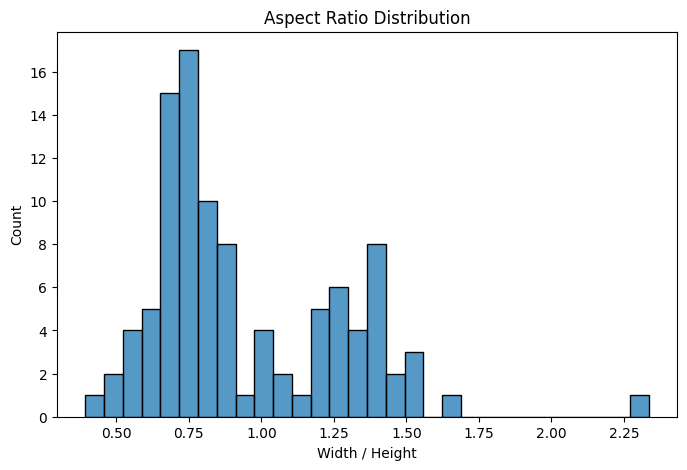

In [ ]:
ratios = [w/h for w,h in sizes]

plt.figure(figsize=(8,5))
sns.histplot(ratios, bins=30)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.show()

### Color Distribution Analysis in Artwork Images

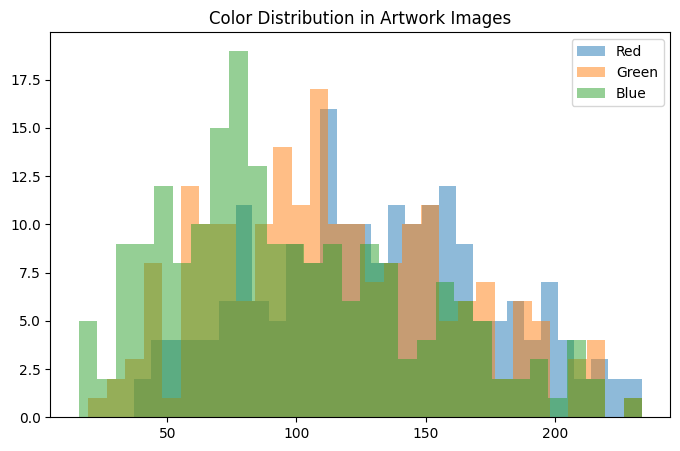

In [ ]:
import numpy as np

avg_colors = []

for img_name in artists[:200]:
    img_path = os.path.join(resized_path, img_name)
    img = Image.open(img_path).convert("RGB")

    img_array = np.array(img)
    avg_color = img_array.mean(axis=(0,1))

    avg_colors.append(avg_color)

avg_colors = np.array(avg_colors)

plt.figure(figsize=(8,5))
plt.hist(avg_colors[:,0], bins=30, alpha=0.5, label="Red")
plt.hist(avg_colors[:,1], bins=30, alpha=0.5, label="Green")
plt.hist(avg_colors[:,2], bins=30, alpha=0.5, label="Blue")

plt.legend()
plt.title("Color Distribution in Artwork Images")
plt.show()

### Image Brightness Analysis

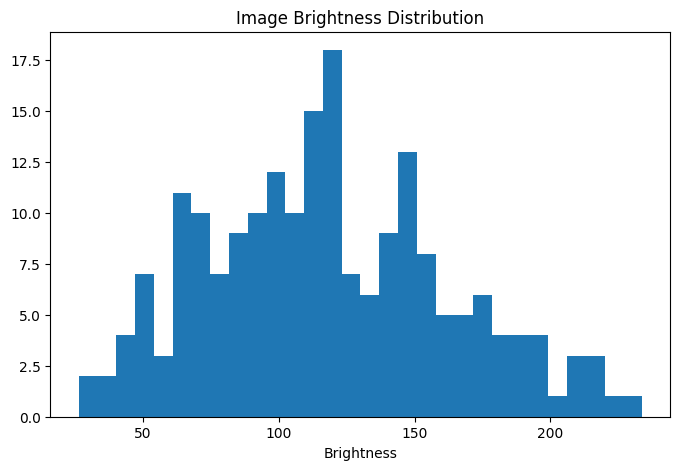

In [ ]:
brightness = []

for img_name in artists[:200]:
    img_path = os.path.join(resized_path, img_name)
    img = Image.open(img_path).convert("L")  # grayscale

    img_array = np.array(img)
    brightness.append(img_array.mean())

plt.figure(figsize=(8,5))
plt.hist(brightness, bins=30)

plt.title("Image Brightness Distribution")
plt.xlabel("Brightness")
plt.show()

### Emotion Estimation Based on Image Brightness

In [ ]:
emotion_labels = []

for b in brightness:
    if b > 170:
        emotion_labels.append("Joy")
    elif b > 100:
        emotion_labels.append("Calm")
    else:
        emotion_labels.append("Sadness")

import pandas as pd

emotion_df = pd.DataFrame({
    "Brightness": brightness,
    "Emotion": emotion_labels
})

emotion_df.head()

,Brightness,Emotion
0,70.689227,Sadness
1,107.656463,Calm
2,44.145559,Sadness
3,104.040213,Calm
4,187.872073,Joy


### Distribution of Estimated Emotions (Joy, Calm, Sadness)

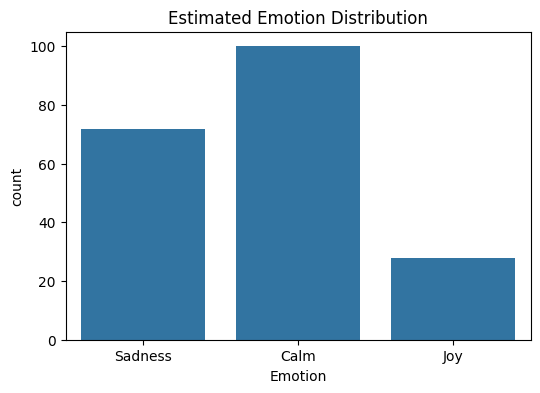

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Emotion", data=emotion_df)

plt.title("Estimated Emotion Distribution")
plt.show()

## Random Sample Images from the Dataset

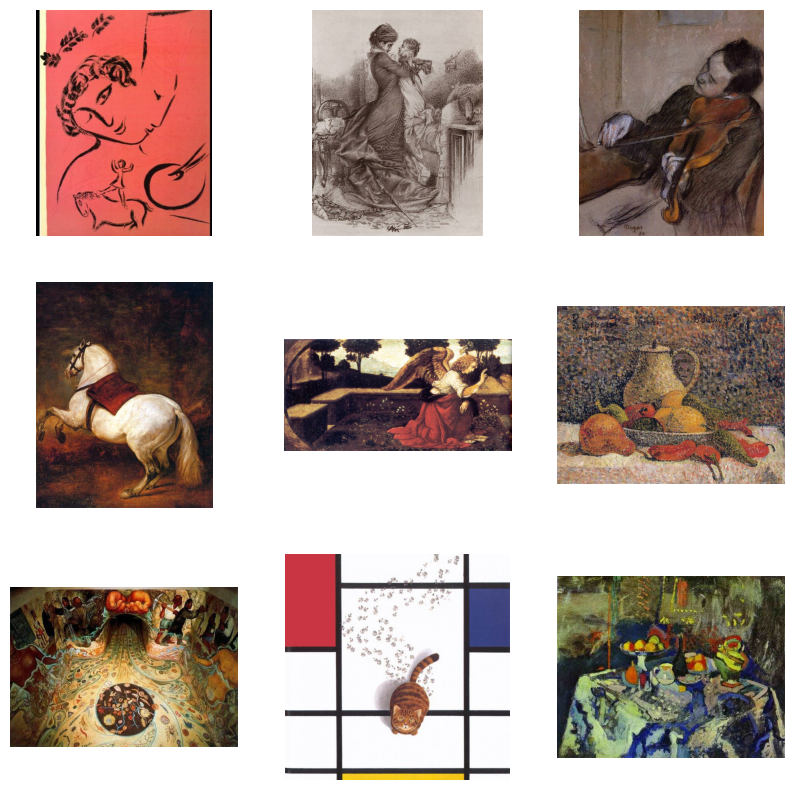

In [ ]:
import random

plt.figure(figsize=(10,10))

for i in range(9):

    img_name = random.choice(artists)
    img_path = os.path.join(resized_path, img_name)

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

## Total Number of Images in the Dataset

In [ ]:
print("Total number of images:", len(artists))

Total number of images: 8683


## Key Insights from EDA

- The dataset contains more than 8000 artwork images from multiple artists.
- Artists include famous painters such as Van Gogh, Monet, and Leonardo da Vinci.
- Image sizes vary significantly, which requires resizing before training the generative model.
- Color distribution and brightness analysis suggest variations that may correspond to different emotional tones in the artworks.
- Estimated emotion labels (Joy, Calm, Sadness) were generated using brightness heuristics to support emotion-aware generation.
- The dataset provides diverse artistic styles suitable for training a multi-artist generative model.